Found 800 files belonging to 2 classes.
Found 100 files belonging to 2 classes.
Found 100 files belonging to 2 classes.
Classes: ['IxoraChinensis', 'IxoraCoccinea']


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,481 (56.38 MB)

 Trainable params: 65,793 (257.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 162s 6s/step - accuracy: 0.5650 - loss: 0.9310 - val_accuracy: 0.7000 - val_loss: 0.4894
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 152s 6s/step - accuracy: 0.7538 - loss: 0.4923 - val_accuracy: 0.8900 - val_loss: 0.3256
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 195s 6s/step - accuracy: 0.8487 - loss: 0.3491 - val_accuracy: 0.9400 - val_loss: 0.2485
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 158s 6s/step - accuracy: 0.8788 - loss: 0.3037 - val_accuracy: 0.9500 - val_loss: 0.2020
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 153s 6s/step - accuracy: 0.9175 - loss: 0.2546 - val_accuracy: 0.9700 - val_loss: 0.1711
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 148s 6s/step - accuracy: 0.9375 - loss: 0.2114 - val_accuracy: 0.9700 - val_loss: 0.1516
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 198s 6s/step - accuracy: 0.9488 - loss: 0.1836 - val_accuracy: 0.9700 - val_loss: 0.1368
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 153s 6s/step - accuracy: 0.9513 - loss: 0.1685 - val_accuracy: 0.9700 - v

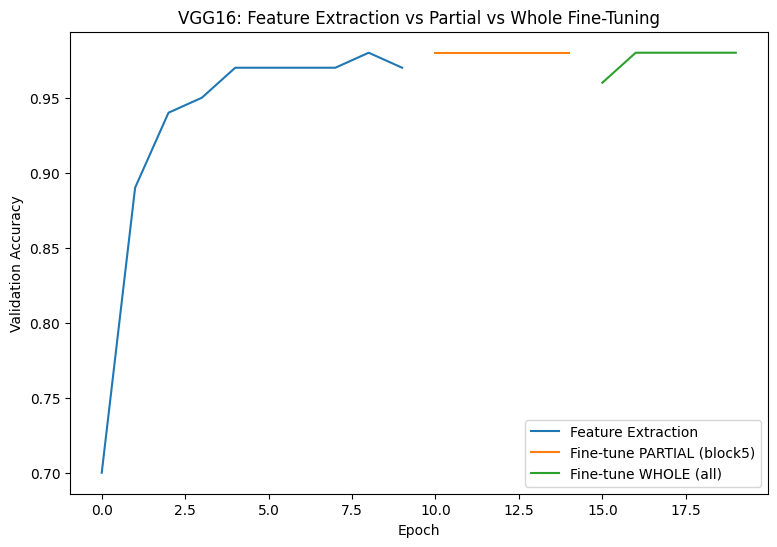

Model saved successfully.


In [13]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras import layers, models
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS_FEATURE = 10
EPOCHS_FINE = 5

train_dir = "Project/Image/train"
val_dir   = "Project/Image/val"
test_dir  = "Project/Image/test"

# Load Dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="binary", color_mode="rgb"
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="binary", color_mode="rgb"
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="binary", shuffle=False, color_mode="rgb"
)

print("Classes:", train_ds.class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)
test_ds  = test_ds.prefetch(AUTOTUNE)

# Data Augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# Build Model (Feature Extraction) - VGG16
base_model = VGG16(weights="imagenet", include_top=False, input_shape=(224,224,3))
base_model.trainable = False

inputs = layers.Input(shape=(224,224,3))
x = data_augmentation(inputs)
x = layers.Lambda(preprocess_input)(x)   # VGG16 preprocessing (instead of Rescaling)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation="relu")(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model = models.Model(inputs, outputs)
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss="binary_crossentropy",
              metrics=["accuracy"])
model.summary()

# Callbacks
early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
checkpoint = ModelCheckpoint("best_model_vgg16.keras", monitor="val_accuracy", save_best_only=True)

# Stage 1 — Feature Extraction
history_feature = model.fit(
    train_ds, validation_data=val_ds, epochs=EPOCHS_FEATURE, callbacks=[early_stop, checkpoint]
)

# Stage 2A — Fine-Tuning (PARTIAL VGG16: only block5)
base_model.trainable = True
for layer in base_model.layers:
    layer.trainable = layer.name.startswith("block5_")

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss="binary_crossentropy",
              metrics=["accuracy"])
history_partial = model.fit(
    train_ds, validation_data=val_ds, epochs=EPOCHS_FINE, callbacks=[early_stop]
)

# Stage 2B — Fine-Tuning (WHOLE VGG16: unfreeze all)
for layer in base_model.layers:
    layer.trainable = True

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss="binary_crossentropy",
              metrics=["accuracy"])
history_whole = model.fit(
    train_ds, validation_data=val_ds, epochs=EPOCHS_FINE, callbacks=[early_stop]
)

# Evaluate on Test Set
test_loss, test_acc = model.evaluate(test_ds)
print(f"\nTest Accuracy: {test_acc:.4f}")

# Plot Validation Accuracy Comparison
plt.figure(figsize=(9,6))
plt.plot(history_feature.history["val_accuracy"], label="Feature Extraction")

off1 = len(history_feature.history["val_accuracy"])
plt.plot(range(off1, off1 + len(history_partial.history["val_accuracy"])),
         history_partial.history["val_accuracy"], label="Fine-tune PARTIAL (block5)")

off2 = off1 + len(history_partial.history["val_accuracy"])
plt.plot(range(off2, off2 + len(history_whole.history["val_accuracy"])),
         history_whole.history["val_accuracy"], label="Fine-tune WHOLE (all)")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("VGG16: Feature Extraction vs Partial vs Whole Fine-Tuning")
plt.legend()
plt.show()

# Save Final Model
model.save("vgg16_binary_model.keras")
print("Model saved successfully.")